# Coupled Pendulums: Differential Equations and Fourier-Initialized Gradient Descent in Machine Learning
> ©2025-2026 Huy Truong, Andrew Bennett

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ngochuytruong/DIFFQ-assignment/blob/main/notebook.ipynb)

# 🔵 Introduction

## A Single Pendulum

Galileo observed that the period for a swinging pendulum depended only on the length of the pendulum and not on the amplitude. To see why this is so, consider the forces on a pendulum of length $l$, as illustrated below. Gravity pulls down with force $mg$, which has a radial component of $mg\cos(\theta)$ and a transverse component of $mg\sin(\theta)$. The radial component creates tension in the string or rod attaching the mass to the center, while the transverse component causes the pendulum to swing. By Newton's second law, $mx'' = -mg\sin(\theta)$, where the minus sign comes from the pendulum being pushed to reduce the angle. The distance traveled by the pendulum bob, $x$, is given by $l\theta$, where $l$ is the length of the pendulum, so this equation becomes $ml\theta'' = -mg\sin(\theta)$. For small angles, we can make the linear approximation $\sin(\theta)\approx\theta$, and then dividing through by $lm$ we get



$$ \theta''(t) + (g/l) \theta(t) = 0.$$



The solution to this is $A\cos(\omega t + \phi)$, where $A$ and $\phi$ are constants showing the amplitude and phase shift. $\omega$ is the circular frequency, with $\omega = \sqrt{g/l}$. The period is $2\pi/\omega$, so we see the period depends only on the the length $l$.


<div align="center">
  <img width="400" src="https://raw.githubusercontent.com/ngochuytruong/my-data/main/image001.png">
</div>

## Coupled Pemdulums

Imagine two pendulums hanging side by side, connected by a spring. Each pendulum can swing back and forth, but because of the spring, the motion of one affects the other—they're "coupled."

**Setting up the problem:**
- Let $\theta_1(t)$ and $\theta_2(t)$ be the angles (in radians) that each pendulum makes with the vertical at time $t$
- The pendulums have lengths $l_1$ and $l_2$
- Both pendulum bobs have the same mass $m$
- The spring connecting them has stiffness constant $k$

<div align="center">
  <img width="600" src="https://raw.githubusercontent.com/ngochuytruong/my-data/main/image1.png">
</div>


**The equations of motion:**

When the angles stay small (so we can use the approximation $\sin\theta \approx \theta$), Newton's second law and Hooke’s law gives us two coupled differential equations:

$$
m l_1 \theta_1''(t) = - m g \theta_1(t) - k\bigl(l_1 \theta_1(t) - l_2 \theta_2(t)\bigr)
$$

$$
m l_2 \theta_2''(t) = - m g \theta_2(t) + k\bigl(l_1 \theta_1(t) - l_2 \theta_2(t)\bigr)
$$

**What each term means:**

- **Gravity terms** ($-mg\theta_1$ and $-mg\theta_2$): These pull each pendulum back toward vertical. The further a pendulum swings out, the stronger gravity pulls it back.

- **Spring stretch** ($l_1\theta_1 - l_2\theta_2$): This measures how much the spring is stretched or compressed. Since the spring connects points along each pendulum's arc, the stretch depends on both angles and both lengths.

- **Coupling forces**: Notice the spring term has opposite signs in the two equations. This makes physical sense—if the spring pulls pendulum 1 to the right, it must pull pendulum 2 to the left (Newton's third law).





# A Hands-On Exploration of Two Modeling Approaches

Throughout this notebook, we explore two fundamentally different ways to model the same physical system:

> ### 🟣 Approach 1 — Neural network
> Train a model to **learn motion directly from data**, without assuming a specific equation form.

> ### 🟣 Approach 2 — Physics-based model
> Fit a model using the system's **natural oscillation patterns** derived from coupled differential equations.

We then compare the strengths and limitations of each approach — and discover why combining physical insight with data-driven methods often works better than either one alone.

## Data: Measuring the Motion

Our experiment consists of two pendulums of different lengths connected by a spring. We displace them from their vertical resting positions, release them, and record how they swing over time.

**How we capture the motion:**

Using video tracking or angle sensors, we measure the angles $\theta_1(t)$ and $\theta_2(t)$ at regular time intervals. The result is two time series—one for each pendulum—sampled at times $t_1, t_2, t_3, \ldots$

### Data
<a href="https://www.youtube.com/watch?v=sHHUi8X5GU8" target="_blank">
  <img width="500" src="https://i3.ytimg.com/vi/sHHUi8X5GU8/maxresdefault.jpg">
</a>

In [1]:
pip install pandas

In [2]:
# import Python packages we'll need
# install a Python package we need
!pip install torchdiffeq

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
torch.set_default_dtype(torch.float64)

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchdiffeq import odeint_adjoint as odeint

## Loading the Experimental Data

The data comes from a video tracking experiment where we recorded the positions of two pendulum masses over time. The CSV file contains:

| Column | Meaning |
|:-------|:--------|
| `t` | Time in seconds |
| `a_right`, `b_right` | Position of the right mass |
| `a_left`, `b_left` | Position of the left mass |

The raw file has some messy header rows, so we'll clean it up before plotting.

The tracker records horizontal positions $a$ (in meters). Since the arc length traveled by a pendulum bob is $a = l\theta$, we can recover the angle from:

$$\theta = \frac{a}{l}$$

This conversion is applied after loading so that all subsequent analysis works directly with angles $\theta$ rather than raw displacements $x$.

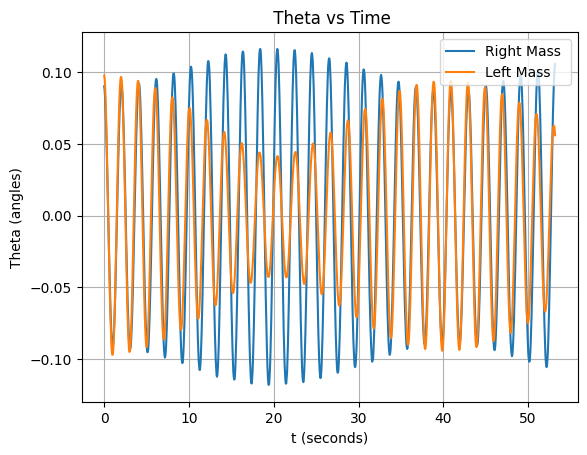

In [3]:
# === Load and Clean the Data ===

csv_url = "https://raw.githubusercontent.com/ngochuytruong/data/main/data-diff-length.csv"

# Read the CSV without assuming any header structure
df = pd.read_csv(csv_url, header=None)

# Assign meaningful column names
df.columns = ['t', 'a_right', 'b_right', 'a_left', 'b_left']

# Remove the first two rows (they contain text headers from the original file)
df = df.iloc[2:].reset_index(drop=True)

# Convert all values to numbers (any non-numeric entries become NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df = df.dropna().reset_index(drop=True)

# === Extract Arrays for Plotting ===

t       = df['t'].to_numpy()
a_right = df['a_right'].to_numpy()
a_left  = df['a_left'].to_numpy()

l_left=1
l_right=1.05
x_left = a_left/l_left
x_right = a_right/l_right

# === Visualize the Motion ===

plt.plot(t, x_right, label='Right Mass ')
plt.plot(t, x_left,  label='Left Mass ')
plt.xlabel('t (seconds)')
plt.ylabel('Theta (angles)')
plt.title(' Theta vs Time')
plt.legend()
plt.grid(True)
plt.show()

# 🔵 A Neural Network Approach

Now let's try a completely different strategy: instead of using physics equations, we'll train a **neural network** to learn the pendulum motion directly from the data.


**The network architecture:**

Our model is a feedforward neural network (multilayer perceptron) with:
- **Input layer**: 1
- **Hidden layers**: Three layers of 128 neurons each, with $\tanh$ activation
- **Output layer**: 2 values (predicted $\theta_1$ and $\theta_2$)

We use $\tanh$ activations because they produce smooth outputs—appropriate for modeling smooth physical motion.

**What the network learns:**

The network knows nothing about pendulums, springs, or differential equations. It simply tries to find a mathematical function that maps time features → positions, adjusting its internal weights to minimize the error between predictions and measured data.

This is a purely **data-driven** approach, which we can compare against our physics-based model.

Number of input features: 1
  - 1 normalized time
  - 0 Fourier terms (sin and cos at 0 frequencies)

Training samples: 844
Test samples: 212

Training the neural network...
--------------------------------------------------
Epoch  400:  Train MSE = 0.992046  |  Test MSE = 1.042216
Epoch  800:  Train MSE = 0.989982  |  Test MSE = 1.165736
Epoch 1200:  Train MSE = 0.986106  |  Test MSE = 1.678647
Epoch 1600:  Train MSE = 0.983405  |  Test MSE = 1.758419
Epoch 2000:  Train MSE = 0.980715  |  Test MSE = 1.828522
--------------------------------------------------
Training complete!


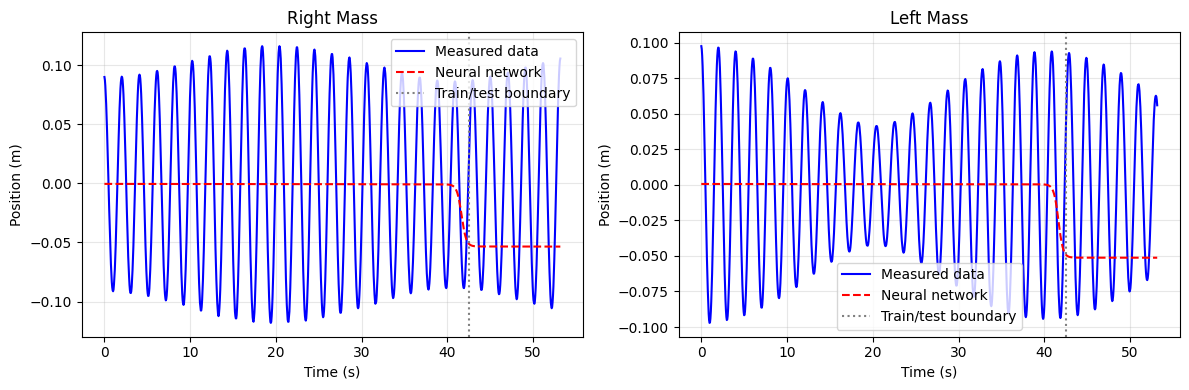


Test set performance:
  Mean Squared Error (MSE):  0.007084
  Root Mean Squared Error:   0.084167 m


In [4]:
# =============================================================================
# NEURAL NETWORK APPROACH TO PREDICTING PENDULUM MOTION
# =============================================================================
#
# Goal: Train a neural network to predict x_right(t) and x_left(t) from time
#       alone, without using any physics equations.
#
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Set random seeds for reproducibility
# -------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# For fully deterministic behavior (may slow down training slightly)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =============================================================================
# STEP 1: CREATE FOURIER FEATURES
# =============================================================================


def make_fourier_features(t_normalized, K=5):
    """
    Convert time into Fourier features.

    Input:  t_normalized - time scaled to [0, 1]
    Output: array of shape (num_timesteps, 1 + 2K)
    """
    features = [t_normalized]

    #for k in range(1, K + 1):
    #    features.append(np.sin(2 * np.pi * k * t_normalized))
    #    features.append(np.cos(2 * np.pi * k * t_normalized))
    for k in range(1, K + 1):
        features.append(np.sin( np.pi * k * t_normalized))
        features.append(np.cos( np.pi * k * t_normalized))

    return np.stack(features, axis=1)


# Normalize time to [0, 1]
t_normalized = (t - t.min()) / (t.max() - t.min())

# Create features
# ============================================
# >>>   CHANGE THESE VALUES FOR QUESTION 1   <
# CHANGE K TO ADD MORE INPUT FEATURES
# ============================================
K = 0 # <-- MODIFY THESE
# ============================================


X = make_fourier_features(t_normalized, K=K)

print(f"Number of input features: {X.shape[1]}")
print(f"  - 1 normalized time")
print(f"  - {2*K} Fourier terms (sin and cos at {K} frequencies)")


# =============================================================================
# STEP 2: PREPARE THE TARGET DATA
# =============================================================================
#
# The network will learn to predict both positions simultaneously.
# We standardize the outputs (subtract mean, divide by std) to help training.
#

# Stack the two position measurements into one array
Y = np.stack([x_right, x_left], axis=1)

# Standardize (makes training more stable)
Y_mean = Y.mean(axis=0, keepdims=True)
Y_std = Y.std(axis=0, keepdims=True)
Y_standardized = (Y - Y_mean) / Y_std

# Convert to PyTorch tensors (explicitly use float32 to avoid dtype errors)
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y_standardized, dtype=torch.float32)


# =============================================================================
# STEP 3: SPLIT INTO TRAINING AND TEST SETS
# =============================================================================
#
# We train on the first 80% of the data and test on the last 20%.
# This tests whether the network can extrapolate into the future.
#

n_total = len(t)
n_train = int(0.8 * n_total)

X_train = X_tensor[:n_train]
X_test = X_tensor[n_train:]
Y_train = Y_tensor[:n_train]
Y_test = Y_tensor[n_train:]

print(f"\nTraining samples: {n_train}")
print(f"Test samples: {n_total - n_train}")

# Create a data loader for batch training
train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=64,
    shuffle=True
)


# =============================================================================
# STEP 4: DEFINE THE NEURAL NETWORK
# =============================================================================
#
# Architecture:
#   Input (11 features)
#       ↓
#   Linear(11 → 128) → Tanh activation
#       ↓
#   Linear(128 → 128) → Tanh activation
#       ↓
#   Linear(128 → 128) → Tanh activation
#       ↓
#   Linear(128 → 2)
#       ↓
#   Output (predicted x_right and x_left)
#
# We use Tanh activations because they produce smooth outputs,
# which is appropriate for smooth physical motion.
#

input_dim = X.shape[1]  # 11 features

model = nn.Sequential(
    nn.Linear(input_dim, 128),   # First hidden layer
    nn.Tanh(),
    nn.Linear(128, 128),          # Second hidden layer
    nn.Tanh(),
    nn.Linear(128, 128),          # Third hidden layer
    nn.Tanh(),
    nn.Linear(128, 2)             # Output layer (two positions)
).float()  # Ensure model uses float32

# Loss function: Mean Squared Error
loss_fn = nn.MSELoss()

# Optimizer: Adam (a popular choice that works well in most cases)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# =============================================================================
# STEP 5: TRAIN THE NETWORK
# =============================================================================
#
# Training loop:
#   1. Feed a batch of data through the network
#   2. Calculate the error (loss) between predictions and actual values
#   3. Backpropagate the error to compute gradients
#   4. Update the weights to reduce the error
#   5. Repeat for many epochs
#

n_epochs = 2000

print("\nTraining the neural network...")
print("-" * 50)

for epoch in range(n_epochs):

    # Training mode
    model.train()

    for X_batch, Y_batch in train_loader:
        # Forward pass: compute predictions
        predictions = model(X_batch)

        # Compute loss
        loss = loss_fn(predictions, Y_batch)

        # Backward pass: compute gradients
        optimizer.zero_grad()
        loss.backward()

        # Update weights
        optimizer.step()

    # Print progress every 400 epochs
    if (epoch + 1) % 400 == 0:
        model.eval()
        with torch.no_grad():
            train_loss = loss_fn(model(X_train), Y_train).item()
            test_loss = loss_fn(model(X_test), Y_test).item()
        print(f"Epoch {epoch+1:4d}:  Train MSE = {train_loss:.6f}  |  Test MSE = {test_loss:.6f}")

print("-" * 50)
print("Training complete!")


# =============================================================================
# STEP 6: MAKE PREDICTIONS
# =============================================================================
#
# Use the trained network to predict positions for all time points.
# Remember to convert back from standardized values to actual positions.
#

model.eval()

with torch.no_grad():
    Y_pred_standardized = model(X_tensor).numpy()

# Convert back to original scale
Y_pred = Y_pred_standardized * Y_std + Y_mean

x_right_nn = Y_pred[:, 0]
x_left_nn = Y_pred[:, 1]


# =============================================================================
# STEP 7: VISUALIZE THE RESULTS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot right mass
axes[0].plot(t, x_right, 'b-', label='Measured data', linewidth=1.5)
axes[0].plot(t, x_right_nn, 'r--', label='Neural network', linewidth=1.5)
axes[0].axvline(t[n_train], color='gray', linestyle=':', label='Train/test boundary')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Right Mass')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot left mass
axes[1].plot(t, x_left, 'b-', label='Measured data', linewidth=1.5)
axes[1].plot(t, x_left_nn, 'r--', label='Neural network', linewidth=1.5)
axes[1].axvline(t[n_train], color='gray', linestyle=':', label='Train/test boundary')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Position (m)')
axes[1].set_title('Left Mass')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# =============================================================================
# STEP 8: EVALUATE PERFORMANCE
# =============================================================================

# Calculate test error in original units
test_mse = np.mean((Y_pred[n_train:] - Y[n_train:]) ** 2)
test_rmse = np.sqrt(test_mse)

print(f"\nTest set performance:")
print(f"  Mean Squared Error (MSE):  {test_mse:.6f}")
print(f"  Root Mean Squared Error:   {test_rmse:.6f} m")

## The challenge

Neural networks struggle to learn oscillatory (back-and-forth) patterns when given only raw time as input. If we just feed in $t = 0, 0.1, 0.2, \ldots$, the network has to somehow figure out on its own that the output should oscillate up and down periodically—this is hard!

**The solution: Fourier features**

Instead of giving the network just the time value, we transform time into a richer set of inputs using sines and cosines:

$$t \rightarrow \left[ t, \, \sin(2\pi t), \, \cos(2\pi t), \, \sin(4\pi t), \, \cos(4\pi t), \, \ldots ,\sin(2K\pi t), \, \cos(2K\pi t)\right]$$

These are called **Fourier features**. Think of them as pre-built oscillating building blocks. The network's job becomes much simpler: instead of learning how to create oscillations from scratch, it just needs to figure out how to combine these waves with the right amplitudes.

With $K = 5$, we get $1 + 2K = 11$ input features:
- 1 feature for the normalized time
- 2 features (sine and cosine) for each of the 5 frequencies


## ❓ Question: Exploring Fourier Features

In the code above, the number of Fourier frequency pairs is controlled by the parameter $K$.

**Currently, $K = 0$, meaning no sine or cosine features are used — only the normalized time $t$ is passed to the network.**

**Task:** Change $K$ from $0$ to 2 and later to $5$, re-run the cell, and write down what you observe.

**Answer:** *(write here)*

# 💡 Evaluating the Neural Network Approach



Looking at the results, the neural network can do a reasonable job fitting the training data—but notice what happens in the test region (after the gray dashed line). The predictions start to drift away from the actual motion.

**Why doesn't the neural network perform better?**

The neural network is a **black box**: it learns patterns from the data without understanding *why* the pendulums move the way they do. It doesn't know about:
- The two natural frequencies of the coupled system
- The spring constant connecting the pendulums
- The lengths and masses involved
- Conservation of energy


**Key Insight:** The NN fits the data but tells us **nothing more**.
---

## Strengths vs. Limitations

| ✅ Strengths | ❌ Limitations |
|:------------|:--------------|
| Easy to set up | Poor extrapolation beyond training data |
| No physics knowledge needed | Parameters are uninterpretable |
| Can fit complex patterns | Needs lots of training data |
| Flexible architecture | Completely a "black box" |

---

### Cannot extract physical meaning
- ❌ Spring constant $k$
- ❌ Natural frequencies $\omega_1, \omega_2$
- ❌ Any interpretable structure

It is just a complicated function that *happens* to fit the data.


# 🔵 Fitting a Two-Frequency Model
Now let's try a different approach: instead of letting a neural network figure out the pattern, we'll use what we know about physics. Since we know the physical properties of our system, we can *calculate* the exact solution directly — no optimization needed.

The approach:
1. Write the equations of motion as a matrix equation
2. Find the eigenvalues and eigenvectors of that matrix
3. The eigenvalues in this setting are negative, we convert eigenvalues to frequencies: $\omega = \sqrt{-\lambda}$
4. Use initial conditions to solve for the amplitudes



**The physics insight:**

Coupled pendulums don't swing randomly — they naturally oscillate at specific frequencies determined by their physical properties (length, mass, spring stiffness). For our system, there are exactly **two natural frequencies**.

Any motion of the coupled pendulums can be written as a combination of oscillations at these two frequencies:

$$
\theta_1(t) = M\cos(\omega_1 t) + N\cos(\omega_2 t)
$$

$$
\theta_2(t) = P\cos(\omega_1 t) + Q\cos(\omega_2 t)
$$

**What do these parameters mean?**

| Parameter | Physical meaning |
|:----------|:-----------------|
| $\omega_1, \omega_2$ | The two natural frequencies of the system |
| $M, N$ | How much each frequency contributes to the motion of pendulum 1 |
| $P, Q$ | How much each frequency contributes to the motion of pendulum 2 |

**Only 6 parameters!**

Compare this to the neural network, which had hundreds of weights. Here we have just 6 numbers to find: $M, N, P, Q, \omega_1, \omega_2$. Each one has a clear physical meaning.

---

## How Do We Find These Parameters?

We'll use **gradient descent** — the same optimization technique used to train neural networks:

1. Start with initial guesses for all 6 parameters
2. Compute predictions using the equations above
3. Calculate the **loss** (mean squared error between predictions and data)
4. Compute the **gradient** (which direction makes the loss increase fastest)
5. Update each parameter by stepping in the *opposite* direction (downhill)
6. Repeat until the loss stops decreasing

After many iterations, we converge to parameter values that best fit the data.

iteration   200   loss 9.446e-03   (right 4.021e-03, left 5.425e-03)
iteration   400   loss 5.469e-05   (right 2.732e-05, left 2.737e-05)
iteration   600   loss 3.104e-05   (right 1.979e-05, left 1.125e-05)
iteration   800   loss 2.775e-05   (right 1.824e-05, left 9.511e-06)
iteration  1000   loss 2.751e-05   (right 1.796e-05, left 9.549e-06)
iteration  1200   loss 2.750e-05   (right 1.792e-05, left 9.587e-06)
iteration  1400   loss 2.750e-05   (right 1.791e-05, left 9.594e-06)
iteration  1600   loss 2.750e-05   (right 1.791e-05, left 9.595e-06)
iteration  1800   loss 2.750e-05   (right 1.791e-05, left 9.595e-06)
iteration  2000   loss 2.750e-05   (right 1.791e-05, left 9.595e-06)


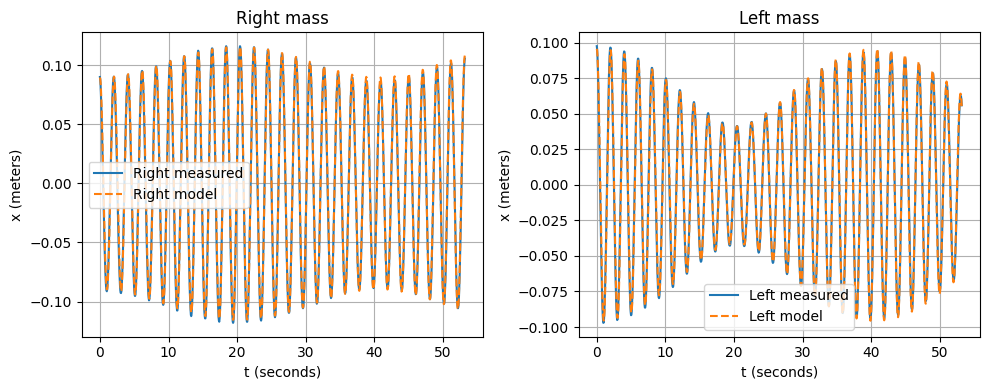

Learned Parameters
  M_learned = -0.013024
  N_learned = 0.102718
  P_learned = 0.027241
  Q_learned = 0.068495
  w1_learned = 3.229152
  w2_learned = 3.074290


In [5]:
torch.manual_seed(13483)

class TwoModeCosine(nn.Module):
    """
    θ1(t) = M cos(w1 t) + N cos(w2 t)
    θ2(t) = P cos(w1 t) + Q cos(w2 t)
    Shared frequencies w1, w2; different amplitudes M,N,P,Q.
    """
    def __init__(self, w1_init, w2_init):
        super().__init__()
        # amplitudes
        self.M = nn.Parameter(torch.randn(1))
        self.N = nn.Parameter(torch.randn(1))
        self.P = nn.Parameter(torch.randn(1))
        self.Q = nn.Parameter(torch.randn(1))
        # angular frequencies (initialized from your values)
        self.w1 = nn.Parameter(torch.tensor([w1_init]))
        self.w2 = nn.Parameter(torch.tensor([w2_init]))


    def forward(self, t):
        """
        t: 1D tensor of shape (N,)
        returns: θ1(t), θ2(t), each shape (N,)
        """
        theta1 = self.M * torch.cos(self.w1 * t) + self.N * torch.cos(self.w2 * t)
        theta2 = self.P * torch.cos(self.w1 * t) + self.Q * torch.cos(self.w2 * t)
        return theta1, theta2


# ============================================
# >>>   CHANGE THESE VALUES FOR QUESTION 2   <
# ============================================
w1_init, w2_init = 3.21, 3.09 # <-- MODIFY THESE
# ============================================


model = TwoModeCosine(w1_init, w2_init)

# convert time and positions to PyTorch tensors (double as well)
tt = torch.tensor(t)
xr = torch.tensor(x_right)
xl = torch.tensor(x_left)


# create an Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-2)  # start with smaller lr for stability

# perform gradient descent
for itr in range(1, 2001):
    optimizer.zero_grad()
    x_hat_r, x_hat_l = model(tt)

    loss_r = F.mse_loss(x_hat_r, xr)
    loss_l = F.mse_loss(x_hat_l, xl)
    loss   = loss_r + loss_l

    loss.backward()
    optimizer.step()

    # output status periodically
    if itr % 200 == 0:
        print(f'iteration {itr:5d}   loss {loss:.3e}   (right {loss_r:.3e}, left {loss_l:.3e})')

# final predictions
with torch.no_grad():
    x_hat_r, x_hat_l = model(tt)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, xr.numpy(), label='Right measured')
plt.plot(t, x_hat_r.numpy(), '--', label='Right model')
plt.xlabel('t (seconds)')
plt.ylabel('x (meters)')
plt.title('Right mass')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, xl.numpy(), label='Left measured')
plt.plot(t, x_hat_l.numpy(), '--', label='Left model')
plt.xlabel('t (seconds)')
plt.ylabel('x (meters)')
plt.title('Left mass')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

M_learned = model.M.detach().numpy()[0]
N_learned = model.N.detach().numpy()[0]
P_learned = model.P.detach().numpy()[0]
Q_learned = model.Q.detach().numpy()[0]
w1_learned = model.w1.detach().numpy()[0]
w2_learned = model.w2.detach().numpy()[0]

print('Learned Parameters')
print(f'  M_learned = {M_learned:.6f}')
print(f'  N_learned = {N_learned:.6f}')
print(f'  P_learned = {P_learned:.6f}')
print(f'  Q_learned = {Q_learned:.6f}')
print(f'  w1_learned = {w1_learned:.6f}')
print(f'  w2_learned = {w2_learned:.6f}')

### What Went Wrong?

The fit didn't capture the true motion. Why?

**The problem: Bad initial guesses**

Gradient descent is a **local** optimization method—it finds the nearest minimum, not necessarily the best one. Our initial guesses were:
```python
w1_init, w2_init = 1.0, 1.0
```

Starting both frequencies at $1.0$ rad/s is likely far from the actual values, so the optimizer got stuck in a poor local minimum.

<div align="center">
  <img width="700" src="https://raw.githubusercontent.com/ngochuytruong/my-data/c76d40e6c5d07cec68667bb544b0b2a56c390baf/loss.png">
  
  *Training loss*
</div>





### How to Find Better Initial Guesses

When gradient descent gets stuck in a bad local minimum, we need smarter starting points.

---

Physical Intuition:

We know from physics that a simple pendulum oscillates with frequency:

$$\omega = \sqrt{\frac{g}{l}}$$

For our pendulums with $l_1 = 1.05$ m and $l_2 = 1.0$ m, ignoring the spring gives us rough estimates:
$$\omega_1 \approx \sqrt{\frac{9.8}{1.05}} \approx 3.05 \text{ rad/s}$$
$$\omega_2 \approx \sqrt{\frac{9.8}{1.0}} \approx 3.13 \text{ rad/s}$$

---

 Experimental Check

Look at the plot of the measured motion:
- Count how many complete oscillations occur in a known time interval
- Divide to get the frequency in Hz
- Multiply by $2\pi$ to convert to rad/s

For example, if you see roughly 5 oscillations in 10 seconds:

$$f \approx 0.5 \text{ Hz} \quad \Rightarrow \quad \omega \approx 2\pi \times 0.5 \approx 3.1 \text{ rad/s}$$

---

---

## ❓ Question: Testing Different Initial Guesses

Now it's your turn to experiment with initial frequency values and see how they affect the optimization.

### Your Task

Find the code cell with `w1_init` and `w2_init`, change the values, and re-run the fitting process.

Try this combination:
- `w1_init, w2_init = 3.13, 3.05`


### Questions to Answer

Does the combination produce a good fit?


*Write your observations here:*

---

# 🔵 Finding the Natural Frequencies via the Fast Fourier Transform

What if we don't know the mass, spring constant, or lengths? We can find $\omega_1$ and $\omega_2$ directly from the measured motion — no physical parameters needed.

**The core idea:**

The Fourier Transform breaks a signal into its individual frequencies, like identifying which notes are being played in a musical chord. Since our pendulum motion is approximately a sum of just two cosines:

$$\theta(t) \approx A\cos(\omega_1 t) + B\cos(\omega_2 t)$$

the spectrum should show exactly **two sharp peaks**, one for each natural frequency.

**The mathematics:**

The FFT takes our discrete time-series $x(t_0), x(t_1), \ldots, x(t_{N-1})$, sampled at intervals $\Delta t$, and computes:

$$\hat{x}_k = \sum_{n=0}^{N-1} x(t_n)\, e^{-i \cdot 2\pi kn / N}$$

The magnitude $|\hat{x}_k|$ tells us how strongly frequency $\omega_k = \frac{2\pi k}{N \Delta t}$ is present in the signal. A large spike means that frequency dominates the motion.

**In practice:**

1. Apply the FFT to $x_{\text{right}}(t)$
2. Look for the two biggest peaks in the spectrum
3. Read off the frequencies

This is a purely *data-driven* approach: the frequencies reveal themselves from the signal alone.

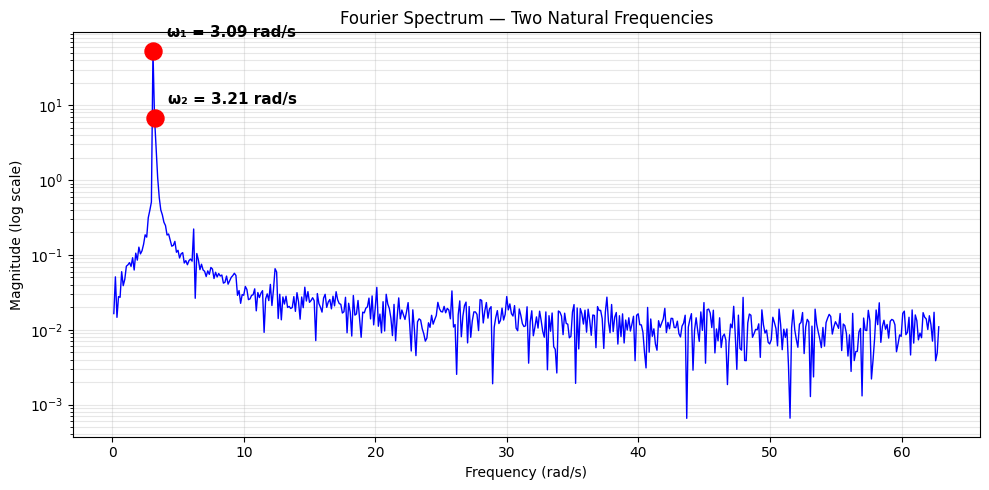

Two natural frequencies from FFT:
  ω₁ = 3.0940 rad/s
  ω₂ = 3.2130 rad/s


In [7]:
# =============================================================================
# FOURIER SPECTRUM — FINDING THE TWO MAIN PEAKS
# =============================================================================

# Compute the FFT
dt = t[1] - t[0]
N = len(t)
freqs = np.fft.rfftfreq(N, d=dt)
omega = 2 * np.pi * freqs
fft_magnitude = np.abs(np.fft.rfft(x_right))

# Find the two largest peaks (ignoring DC at index 0)
fft_no_dc = fft_magnitude[1:]
omega_no_dc = omega[1:]

sorted_indices = np.argsort(fft_no_dc)
peak1_idx = sorted_indices[-1]  # largest
peak2_idx = sorted_indices[-2]  # second largest

w1_fft = omega_no_dc[peak1_idx]
w2_fft = omega_no_dc[peak2_idx]

# Ensure w1 < w2
if w1_fft > w2_fft:
    w1_fft, w2_fft = w2_fft, w1_fft
    peak1_idx, peak2_idx = peak2_idx, peak1_idx

# Plot with log scale to make both peaks visible
plt.figure(figsize=(10, 5))

plt.plot(omega_no_dc, fft_no_dc, 'b-', linewidth=1)
plt.scatter([w1_fft, w2_fft],
            [fft_no_dc[peak1_idx], fft_no_dc[peak2_idx]],
            color='red', s=150, zorder=5)

# Label the two peaks
plt.annotate(f'ω₁ = {w1_fft:.2f} rad/s',
             (w1_fft, fft_no_dc[peak1_idx]),
             textcoords="offset points", xytext=(10, 10),
             ha='left', fontsize=11, fontweight='bold')

plt.annotate(f'ω₂ = {w2_fft:.2f} rad/s',
             (w2_fft, fft_no_dc[peak2_idx]),
             textcoords="offset points", xytext=(10, 10),
             ha='left', fontsize=11, fontweight='bold')

plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (log scale)')
plt.title('Fourier Spectrum — Two Natural Frequencies')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Print results
print(f"Two natural frequencies from FFT:")
print(f"  ω₁ = {w1_fft:.4f} rad/s")
print(f"  ω₂ = {w2_fft:.4f} rad/s")

---

## ❓Question:


Find the code cell with `w1_init` and `w2_init` (same place as Question 2), change the values to your computed $\omega_1$ and $\omega_2$ from Question 3, and re-run the fitting process.

### Questions to Answer

1. How does the fit quality compare to when we used `w1_init, w2_init = 1.0, 1.0`?
2. Do the optimized values stay close to your initial guesses?
3. What does this tell you about combining physics with machine learning?

*Your answers:*



---

---

# 💡 Key Insights

We explored three approaches to modeling the coupled pendulum system:

| Approach | How It Works |
|:---------|:-------------|
| **Neural Network** | Learns patterns directly from data |
| **Physics-Based** | Uses equations from physics laws |
| **Combined** | Uses physics to guide machine learning |

---

## What We Discovered

### 1. Neural networks are powerful but limited

The neural network fit the training data well but struggled to predict beyond it—it learned *what* the motion looks like without understanding *why*.

### 2. Initial guesses matter—a lot

Bad initial guesses led to poor results because the optimizer got stuck in a **local minimum**—a solution that looks okay locally but isn't the best overall.

### 3. Physics rescues machine learning

Using physics to compute good initial guesses helped gradient descent converge to the correct solution, avoiding bad local minima.

### 4. Data can also guide us

The **Fourier transform** let us extract frequencies directly from the data—a data-driven alternative when physics is unknown.



## Key Insights: Comparing Approaches

|                          | **NN Alone** | **Diff. Eq. + ML** | **Diff. Eq. + FT + ML** |
|--------------------------|--------------|---------------------|--------------------------|
| Fits training data well  | ✓            | ~                   | ✓                        |
| Excellent extrapolation  | ×            | ~                   | ✓                        |
| Interpretable parameters | ×            | ✓                   | ✓                        |
| No physics knowledge needed | ✓         | ×                   | ~                        |
| Works with limited data  | ×            | ~                   | ~                        |

## 💡 The Complete Pipeline: Diff. Eq. + Fourier Transform + ML

`Differential Equations` → `Fourier Transform` → `ML / Gradient Descent`

- Differential Equations → Fourier Transform: **# of frequencies**
- Fourier Transform → ML / Gradient Descent: **Initial guess**

All three contribute to: **Better Results!**

**Take-Home Message:**

> Combining **differential equations**, **Fourier analysis**, and **machine learning** leverages the strengths of each approach.


## ❓Question: Choosing the Right Modeling Approach

**Real-world scenario:**

You're an engineer designing a suspension system for a new car. The system involves springs, dampers, and linkages that interact in complex ways. You have sensor data from test drives, but some damper properties are unknown — they change with temperature and wear. You need a model that predicts how the car handles on roads it hasn't been tested on.

**Write a paragraph (or two) discussing:**

Would you use a physics-based model, a neural network, or a combination of both? What are the advantages and disadvantages of each approach?

*Your answer:*